Mesh: Cube
Mat prop: neo hookean
growth law: square root of strain tensor component 

This section of code define the workspace, it reads the mesh file, convert into managable format (i think if you want your mesh to have multiple mat prop, you need to define more domain here)

In [ ]:
import meshio
from dolfin import *
import numpy as np
import os

# ======================================================
# 1. Setup and mesh conversion
# ======================================================
os.chdir(os.path.dirname(os.path.realpath(__file__)))

# --- Convert .msh to .xdmf if not already present ---
if not (os.path.exists("hyper_cube_domain.xdmf") and os.path.exists("hyper_cube_boundaries.xdmf")):
    msh = meshio.read("hyper_cube.msh")
    cells_vol = msh.get_cells_type("tetra")
    cell_data_vol = msh.get_cell_data("gmsh:physical", "tetra")
    meshio.write_points_cells(
        "hyper_cube_domain.xdmf",
        msh.points,
        [("tetra", cells_vol)],
        cell_data={"name_to_read": [cell_data_vol]}
    )

    cells_surf = msh.get_cells_type("triangle")
    cell_data_surf = msh.get_cell_data("gmsh:physical", "triangle")
    meshio.write_points_cells(
        "hyper_cube_boundaries.xdmf",
        msh.points,
        [("triangle", cells_surf)],
        cell_data={"name_to_read": [cell_data_surf]}
    )

# ======================================================
# 2. Load mesh and define spaces
# ======================================================
mesh = Mesh()
with XDMFFile("hyper_cube_domain.xdmf") as infile:
    infile.read(mesh)

mvc_bnd = MeshValueCollection("size_t", mesh, mesh.topology().dim() - 1)
with XDMFFile("hyper_cube_boundaries.xdmf") as infile:
    infile.read(mvc_bnd, "name_to_read")
boundaries = MeshFunction("size_t", mesh, mvc_bnd)

V = VectorFunctionSpace(mesh, "CG", 1)


This section is what need to be modified, Boundary conditions are defined in here. The surfaces which BC are applied to are tagged in Gmsh (abaquas can do similar thing so i should be able to switch to it later without any issue). Here i recall the ID and clamp it y dirichletBC. The loading BC work similarly, I recall the ID, choose the applied load direction by adjusting the unit vector, then choose a load value. Load step you have to test how refine you want it  to  be, if the step is too large it will give you convergence issue. Now the simplest way is to refine it by adding more step. The rest is about Neo hookean, or some kind of strain energy approach for  hyperelastic problem.

In [ ]:
# ======================================================
# 3. Boundary conditions and material parameters
# ======================================================
zero = Constant((0.0, 0.0, 0.0))
clamp_id = 13
bc_clamp = DirichletBC(V, zero, boundaries, clamp_id)

E = 1.0
nu = 0.3
mu = Constant(E / (2*(1+nu)))
lmbda = Constant(E*nu / ((1+nu)*(1-2*nu)))

u = Function(V)
du = TrialFunction(V)
v = TestFunction(V)

d = mesh.geometry().dim()
I = Identity(d)

# ======================================================
# 4. Loading Phase (step load)
# ======================================================
load_steps = 100
target_load = 1e-1
pressure_id = 14
pressure_base = as_vector((0, -1, 0.0))
load_factor = Constant(0.0)
pressure_vec = load_factor * pressure_base
ds_measure = Measure("ds", domain=mesh, subdomain_data=boundaries)

F = I + grad(u)
C = F.T*F
Ic = tr(C)
J = det(F)
psi = (mu/2)*(Ic - 3) - mu*ln(J) + (lmbda/2)*(ln(J))**2

Pi_total = psi*dx - dot(pressure_vec, u)*ds_measure(pressure_id)
F_res = derivative(Pi_total, u, v)
J_res = derivative(F_res, u, du)

this is how it loop the load step. I have a version that within this for loop, it will check whether the initial step of the current step is the solution of previous step, if not it will break the loop. Maybe i will add it back later.

In [ ]:
xdmf_load = XDMFFile(mesh.mpi_comm(), "u_loading_phase.xdmf")
xdmf_load.parameters["flush_output"] = True
xdmf_load.parameters["functions_share_mesh"] = True

print("=== Loading Phase ===")
for step in range(1, load_steps + 1):
    load_factor.assign(step / load_steps * target_load)
    solve(F_res == 0, u, bcs=[bc_clamp], J=J_res)
    xdmf_load.write(u, float(step))
xdmf_load.close()
print("✅ Loading phase finished and saved.")


this is the remodeling phase. For this simple growth law, you define the growth parameter in the first few lines, (notice that  the growth_step here doesnt work like load step in previous section, it essentially is how long you want this growth section to last. If make it 1000 it will run 10 times longer so to have more time to growth. But for this growth law, it will have convergence issue, either in the growth loop section or the unloading section,when growth step pass 500 or less, i think this is because it growth too much and the mesh become too distort). growth_rate and dt_growth have linear relationship, they just multiply each other with the strain tensor, now it's like how big the growth you want in each step. Then the rest is it will calculate the F_g, and do the F = F_e * F _g eqaution, and keep looping it until it reach the defined growth step.

more detail about the F = F_elastic * F_ growth relationship. The code here first calculate the F, then extract the F_e by multiplying inv(Fg), this F_e is then use to get strain tensor, which is the input of the growth law. The name F_total, Fe, F_current are quite misleading i think. Check this image to give a better idea, 

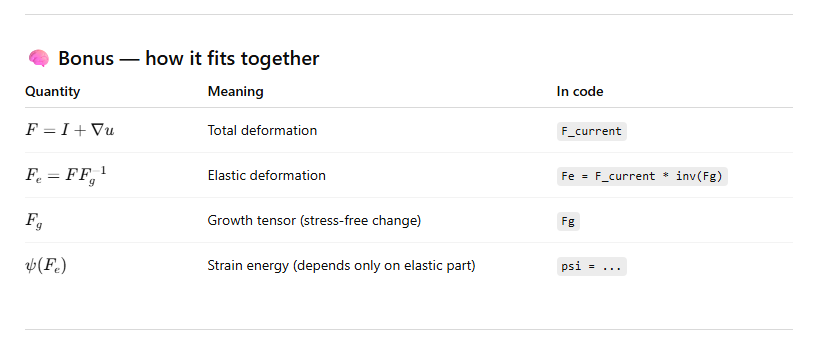

In [ ]:
# ======================================================
# 5. Remodeling Phase (maintain load)
# ======================================================
growth_steps = 100
dt_growth = 0.1
growth_rate = 0.05
dx = Measure("dx", domain=mesh, metadata={"quadrature_degree": 4})

Fg_space = TensorFunctionSpace(mesh, "CG", 1)
Fg = Function(Fg_space)
Fg.assign(project(Identity(d), Fg_space))
incr = Function(Fg_space)

# Keep load at final value
load_factor.assign(target_load)
pressure_vec = load_factor * pressure_base

xdmf_growth = XDMFFile(mesh.mpi_comm(), "u_growth_phase.xdmf")
xdmf_growth.parameters["flush_output"] = True
xdmf_growth.parameters["functions_share_mesh"] = True

xdmf_Fg = XDMFFile(mesh.mpi_comm(), "Fg_growth_phase.xdmf")
xdmf_Fg.parameters["flush_output"] = True
xdmf_Fg.parameters["functions_share_mesh"] = True

print("=== Remodeling Phase ===")
for gstep in range(1, growth_steps + 1):
    # --- Update elastic deformation using current u ---
    F_current = I + grad(u)
    Fe = F_current * inv(Fg)
    E_tensor = 0.5*(Fe.T*Fe - I)
    strain_mag = sqrt(inner(E_tensor, E_tensor))

    # --- Growth increment ---
    incr_expr = Identity(d)*(1.0 + growth_rate*strain_mag*dt_growth)
    incr.assign(project(incr_expr, Fg_space))
    Fg.assign(project(incr*Fg, Fg_space))

    # --- Total deformation after growth ---
    F_tot = F_current * inv(Fg)
    C = F_tot.T*F_tot
    Ic = tr(C)
    J = det(F_tot)
    psi = (mu/2)*(Ic - 3) - mu*ln(J) + (lmbda/2)*(ln(J))**2

    # --- Update variational problem ---
    Pi_total_growth = psi*dx - dot(pressure_vec, u)*ds_measure(pressure_id)
    F_res_growth = derivative(Pi_total_growth, u, v)
    J_res_growth = derivative(F_res_growth, u, du)

    # --- Solve ---
    solve(F_res_growth == 0, u, bcs=[bc_clamp], J=J_res_growth)

    # --- Save ---
    if gstep % 10 == 0:
        avg_strain = assemble(strain_mag*dx)/assemble(1*dx)
        print(f"[Growth Step {gstep}] Avg strain = {avg_strain:.6e}")

    xdmf_growth.write(u, float(gstep))
    if gstep % 20 == 0:
        xdmf_Fg.write(Fg, float(gstep))

xdmf_growth.close()
xdmf_Fg.close()
print("✅ Remodeling phase finished and saved.")


The rest is unloading phase, nothing sepecial, just increase the number of unload step if convergence issue occurs.

In [ ]:
# ======================================================
# 6. Unloading Phase (gradual release from remodeled state)
# ======================================================
unload_steps = 100
xdmf_unload = XDMFFile(mesh.mpi_comm(), "u_unloading_phase.xdmf")
xdmf_unload.parameters["flush_output"] = True
xdmf_unload.parameters["functions_share_mesh"] = True

print("=== Unloading Phase ===")
for step in range(1, unload_steps + 1):
    # Gradually reduce load
    load_factor.assign(target_load * (1 - step / unload_steps))
    pressure_vec = load_factor * pressure_base

    # --- Compute total deformation including remodeling ---
    F_current = I + grad(u)
    F_tot = F_current * inv(Fg)  # important: include growth tensor
    C = F_tot.T * F_tot
    Ic = tr(C)
    J = det(F_tot)
    psi = (mu / 2) * (Ic - 3) - mu * ln(J) + (lmbda / 2) * (ln(J))**2

    # --- Define variational problem with updated load ---
    Pi_total_unload = psi * dx - dot(pressure_vec, u) * ds_measure(pressure_id)
    F_res_unload = derivative(Pi_total_unload, u, v)
    J_res_unload = derivative(F_res_unload, u, du)

    # --- Solve equilibrium ---
    solve(F_res_unload == 0, u, bcs=[bc_clamp], J=J_res_unload)

    # --- Save displacement ---
    xdmf_unload.write(u, float(step))

xdmf_unload.close()
print("✅ Unloading phase finished and saved.")